 # Crystal parametrisation
The goal of this notebook is to parametrise the crystal efficiency v. losses as a function of bending radius and crystal length

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import xpart as xp
import xobjects as xo

import crystal_extraction.utils as utils
import crystal_extraction.plotters as plotters
from crystal_extraction.dummy_crystal import DummyCrystal

plotters.my_mpl_style()


## Method

For a given kick angle, we will characterise the single-pass efficiency and the losses as a function of the crystal length and bending radius. We will use the following method:

1. Generate several particles perfectly aligned with the crystal
2. Track them through the crystal
3. Measure the losses: made up of particles actually lost (state < 0)
4. Fit two Gaussians, one centred around zero (no kick) and one centred around the kick angle. We consider lost particles that are outside n-sigma from both Gaussians.
5. The efficiency is calculated by looking at particles within n-sigma from the kick angle Gaussian. 

In [4]:
# I take the bending radius of the SPS as a fixed val

sps_cry = DummyCrystal()
sps_cry.active_length = 2.5e-3
sps_cry.mu_kick_chan = 40e-6
print("Bending radius: ", sps_cry.bending_radius)
print("Length: ", sps_cry.active_length)

Bending radius:  14.7
Length:  0.000588


In [5]:
from scipy.optimize import curve_fit
from functools import partial
from math import sqrt, ceil

# Define individual Gaussian functions
def gauss(x, std_dev, amplitude, mean=0):
    return amplitude * np.exp(-0.5 * ((x - mean) / std_dev)**2) / (std_dev * np.sqrt(2 * np.pi))

# Combine two Gaussians with individual amplitudes
def double_gauss(x, mean1, std_dev1, amplitude1,
                 mean2, std_dev2, amplitude2):
    return gauss(x, std_dev1, amplitude1, mean=mean1) + gauss(x, std_dev2, amplitude2, mean=mean2)

Kick angle:  9.999999999999999e-05 radius 5 length 0.0005
Kick angle:  0.00015 radius 5 length 0.0007499999999999999
Kick angle:  0.00019999999999999998 radius 5 length 0.001
Kick angle:  0.0003 radius 5 length 0.0014999999999999998
Kick angle:  0.00039999999999999996 radius 5 length 0.002
Kick angle:  0.0005 radius 5 length 0.0025
Kick angle:  0.0007 radius 5 length 0.0035
Kick angle:  0.001 radius 5 length 0.005
Kick angle:  9.999999999999999e-05 radius 10 length 0.001
Kick angle:  0.00015 radius 10 length 0.0014999999999999998
Kick angle:  0.00019999999999999998 radius 10 length 0.002
Kick angle:  0.0003 radius 10 length 0.0029999999999999996
Kick angle:  0.00039999999999999996 radius 10 length 0.004
Kick angle:  0.0005 radius 10 length 0.005
Kick angle:  0.0007 radius 10 length 0.007
Kick angle:  0.001 radius 10 length 0.01
Kick angle:  9.999999999999999e-05 radius 15 length 0.0014999999999999998
Kick angle:  0.00015 radius 15 length 0.00225
Kick angle:  0.00019999999999999998 radi

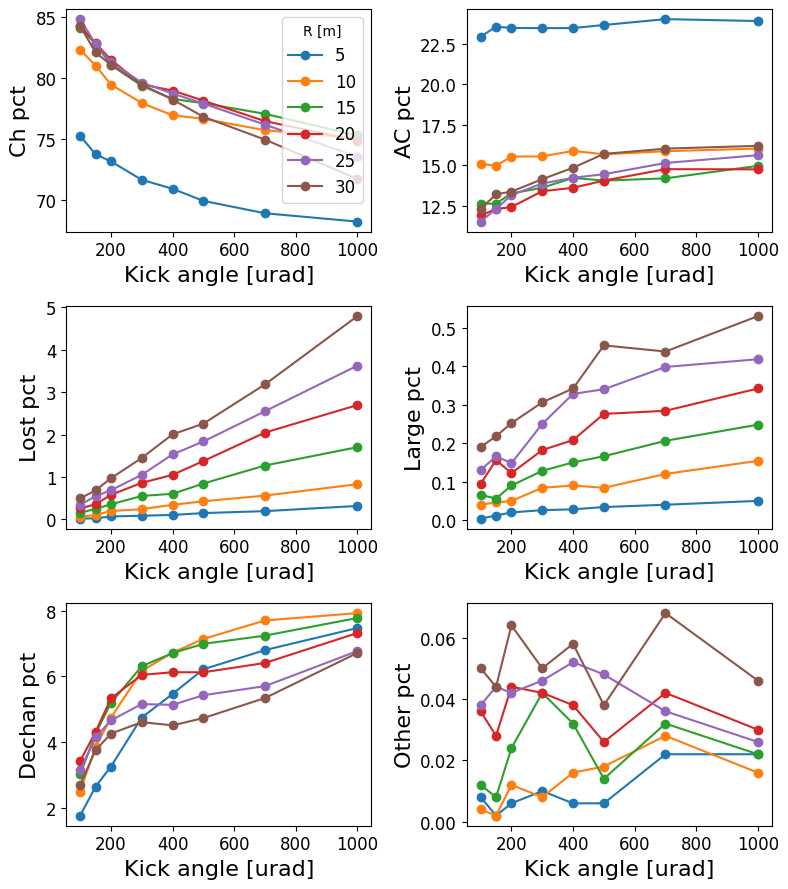

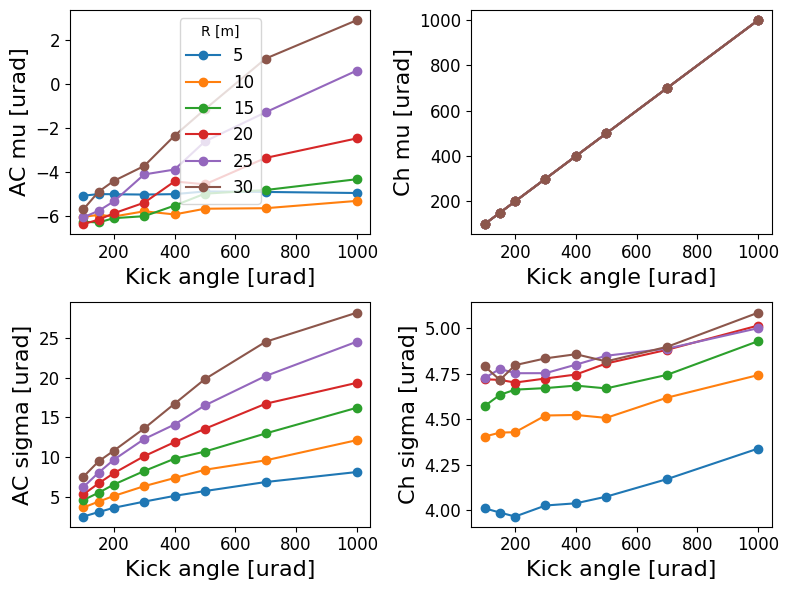

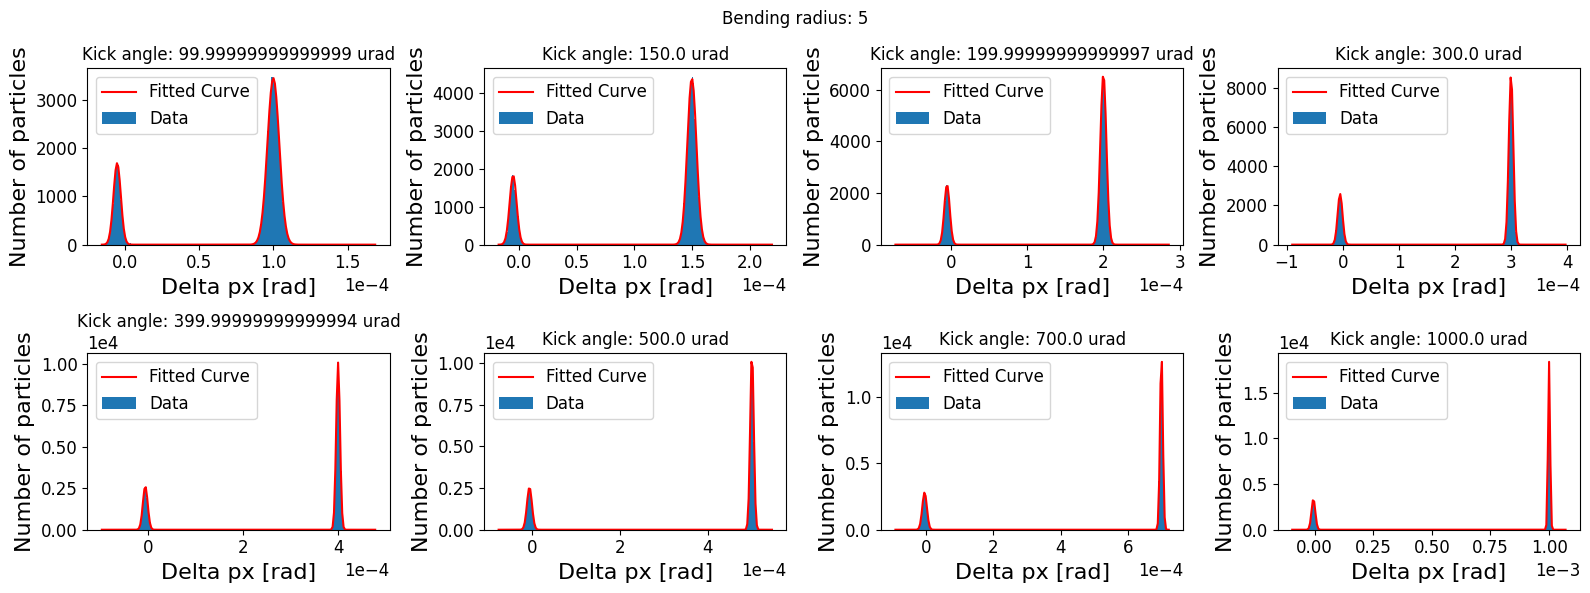

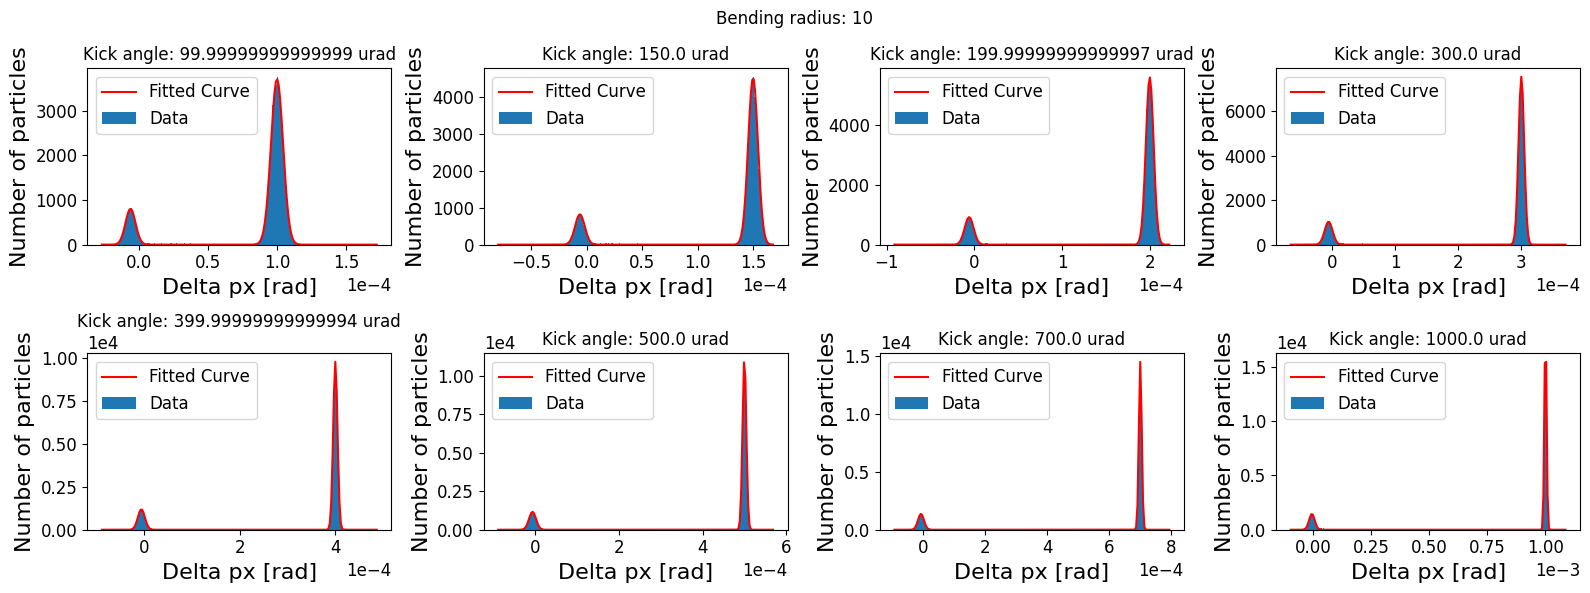

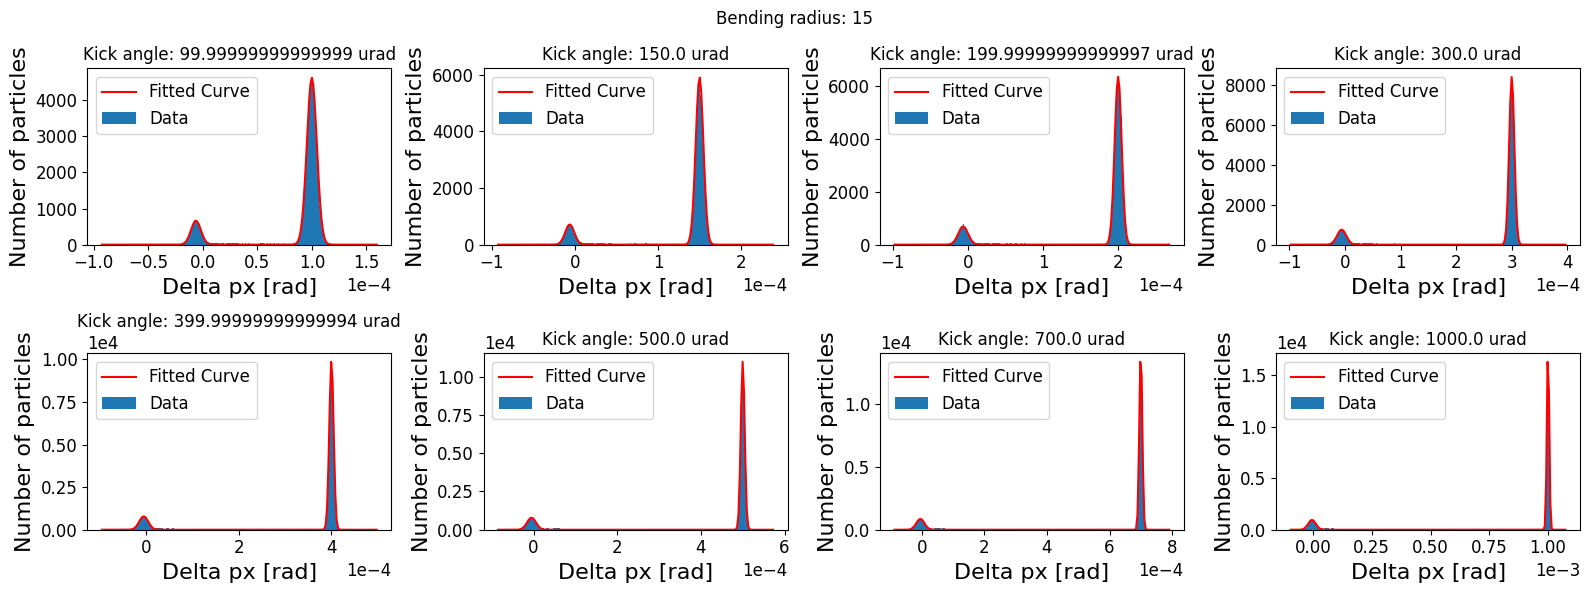

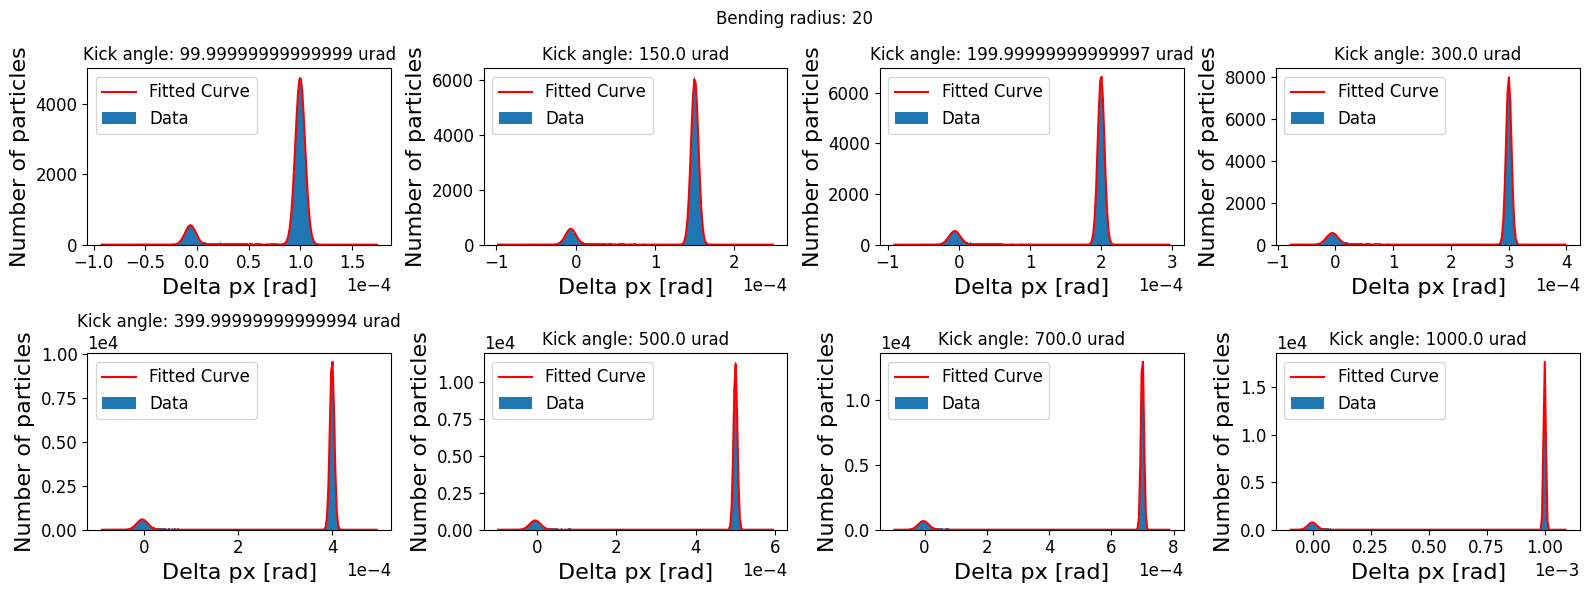

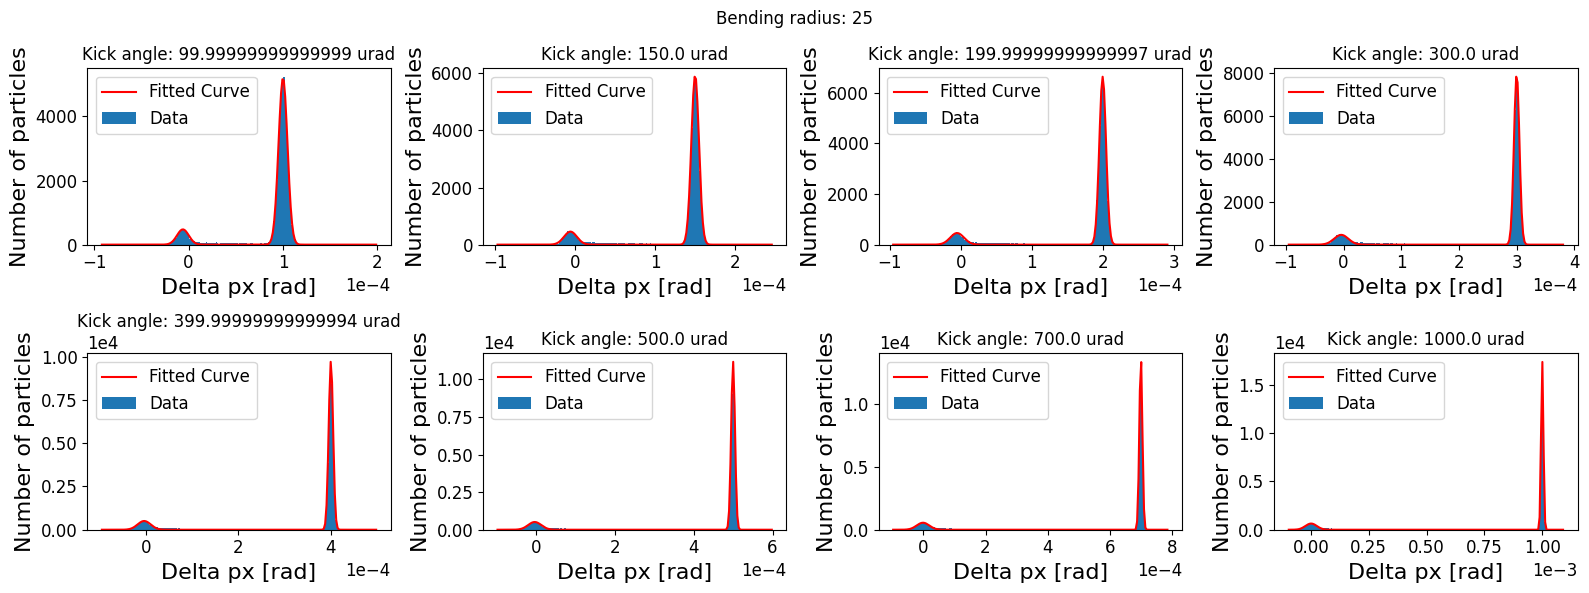

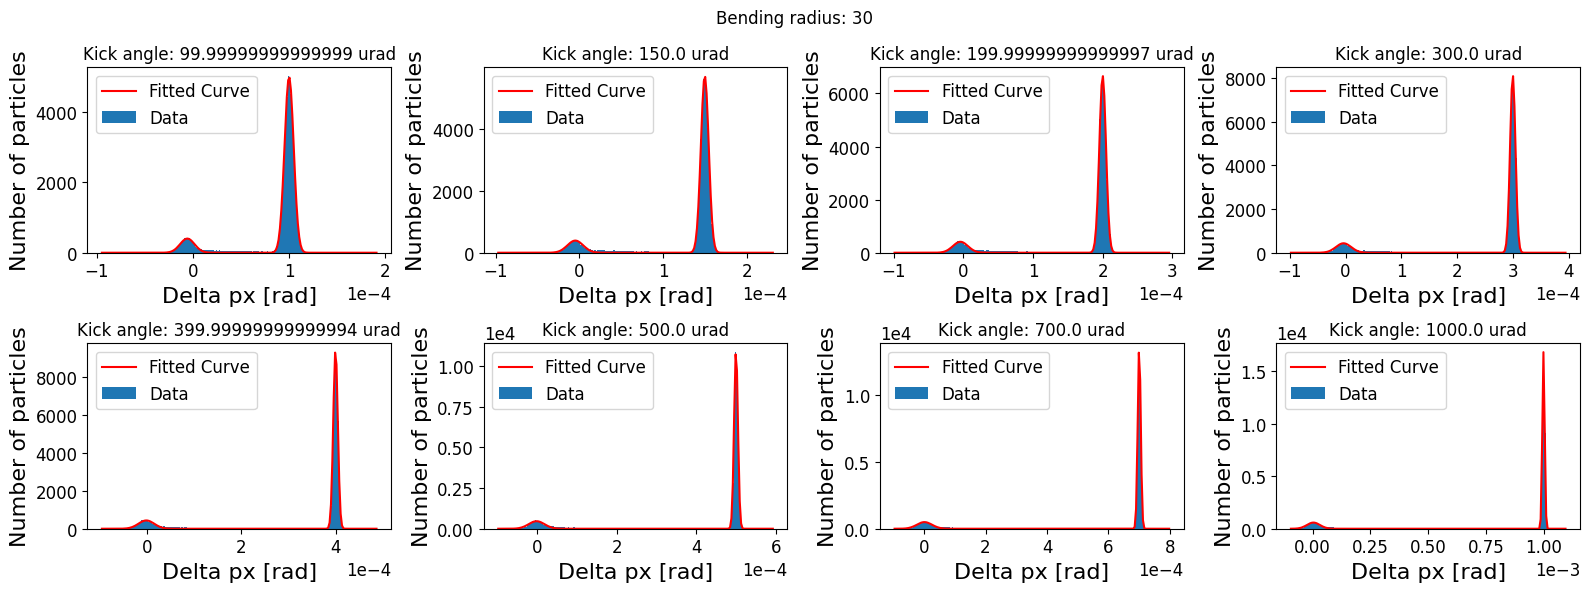

In [6]:
# Regimes are defined in terms of sigma

bending_radii = np.array([5, 10, 15, 20, 25, 30])
kicks = np.array([100, 150, 200, 300, 400, 500, 700, 1000])*1e-6
n_particles = int(50e3)
nbins = 200
sigma_cutoff = 5
p0c = 400e9

f_pct, ax_pct = plotters.subplots(nsubplots=6, col_numbers=[2])
f_stats, ax_stats = plotters.subplots(nsubplots=4, col_numbers=[2])

for bending_radius in bending_radii:
    sps_cry.bending_radius = bending_radius

    lost_pcts = np.zeros_like(kicks)
    other_pcts = np.zeros_like(kicks)
    chan_pcts = np.zeros_like(kicks)
    dechan_pcts = np.zeros_like(kicks)
    ac_pcts = np.zeros_like(kicks)
    large_pcts = np.zeros_like(kicks)
    
    ac_mus = np.zeros_like(kicks)
    ch_mus = np.zeros_like(kicks)
    ac_sigmas = np.zeros_like(kicks)
    ch_sigmas = np.zeros_like(kicks)
    ac_amps = np.zeros_like(kicks)
    ch_amps = np.zeros_like(kicks)
    
    f_fit, ax_fit = plotters.subplots(nsubplots=len(kicks))
    f_fit.suptitle('Bending radius: ' + str(bending_radius))
    
    for i, kick in enumerate(kicks):
        
        # Tracking
        
        sps_cry.mu_kick_chan = kick
        print("Kick angle: ", kick, "radius", sps_cry.bending_radius, "length", sps_cry.active_length)
    
        particles = xp.Particles(p0c=p0c, x=np.zeros(n_particles), px=np.zeros(n_particles), y=np.zeros(n_particles), py=np.zeros(n_particles), zeta=np.zeros(n_particles), delta=np.zeros(n_particles))
        particles._init_random_number_generator()
        cry = sps_cry.build_xsuite_crystal()
        cry.track(particles)
        
        # Analyse the results
            
        all_pxs = particles.px
        lost = particles.state <= 0
        lost_pxs = all_pxs[lost]
        rest_pxs = all_pxs[~lost]
        # Remove some large angle particles by hand
        large_angle = np.logical_or(rest_pxs > kick + 1e-4,
                                     rest_pxs < -1e-4)
        rest_pxs = rest_pxs[~large_angle]
        pxs_hist, pxs_bins = np.histogram(rest_pxs,
                                          bins=nbins)
        pxs_benters = 0.5*(pxs_bins[1:] + pxs_bins[:-1])
        
        
        # Initial guess for the parameters
        initial_guess = [0,
                         sps_cry.sigma_kick_ac,
                         np.max(pxs_hist),
                         kick,
                         sps_cry.sigma_kick_chan,
                         np.max(pxs_hist)]
            
        # Perform the fit
        params, covariance = curve_fit(double_gauss, pxs_benters, pxs_hist, p0=initial_guess)
    
        # Extract fitted parameters
        ac_mu, ac_sigma, ac_amp, ch_mu, ch_sigma, ch_amp = params
    
        # Generate fitted curve
        y_fit = double_gauss(pxs_benters, ac_mu, ac_sigma, ac_amp, ch_mu, ch_sigma, ch_amp)
        
        # Plot the results
        ax_fit[i].bar(pxs_benters, pxs_hist, label='Data', 
               width=pxs_benters[1] - pxs_benters[0])
        ax_fit[i].plot(pxs_benters, y_fit, label='Fitted Curve', color='red')
        ax_fit[i].set_ylabel('Number of particles')
        ax_fit[i].set_xlabel('Delta px [rad]')
        ax_fit[i].set_title('Kick angle: ' + str(kick*1e6) + ' urad')
        ax_fit[i].legend()
        
        # Evaluate performance and save data
        
        lost_pct = np.sum(lost) / n_particles
        lost_pcts[i] = lost_pct
        large_pct = np.sum(large_angle) / n_particles
        large_pcts[i] = large_pct
        chan_pct = np.sum(np.abs(rest_pxs-kick) <= sigma_cutoff*ch_sigma) / n_particles
        chan_pcts[i] = chan_pct
        ac_pct = np.sum(np.abs(rest_pxs-ac_mu) <= sigma_cutoff*ac_sigma) / n_particles
        ac_pcts[i] = ac_pct
        dechan_pct = np.sum(np.logical_and(rest_pxs - ac_mu > sigma_cutoff*ac_sigma,
                                            rest_pxs - kick < -sigma_cutoff*ch_sigma)) / n_particles   
        dechan_pcts[i] = dechan_pct
        other_pct = 1 - chan_pct - ac_pct - lost_pct - large_pct - dechan_pct
        other_pcts[i] = other_pct
    
        ac_mus[i] = ac_mu
        ch_mus[i] = ch_mu
        ac_sigmas[i] = ac_sigma
        ch_sigmas[i] = ch_sigma
        ac_amps[i] = ac_amp
        ch_amps[i] = ch_amp

    # Plot the results
    
    ax_pct[0].plot(kicks*1e6, chan_pcts*100, label=bending_radius, marker='o')
    ax_pct[0].set_ylabel('Ch pct')
    ax_pct[1].plot(kicks*1e6, ac_pcts*100,
               label=bending_radius, marker='o')
    ax_pct[1].set_ylabel('AC pct')
    ax_pct[2].plot(kicks*1e6, lost_pcts*100, label=bending_radius, marker='o')
    ax_pct[2].set_ylabel('Lost pct')
    ax_pct[3].plot(kicks*1e6, large_pcts*100, marker='o', label=bending_radius)
    ax_pct[3].set_ylabel('Large pct')
    ax_pct[4].plot(kicks*1e6, dechan_pcts*100, marker='o', label=bending_radius)
    ax_pct[4].set_ylabel('Dechan pct')
    ax_pct[5].plot(kicks*1e6, other_pcts*100, marker='o', label=bending_radius)
    ax_pct[5].set_ylabel('Other pct')
    

    ax_stats[0].plot(kicks*1e6, ac_mus*1e6, label=bending_radius, marker='o')
    ax_stats[0].set_ylabel('AC mu [urad]')
    ax_stats[1].plot(kicks*1e6, ch_mus*1e6, label=bending_radius, marker='o')
    ax_stats[1].set_ylabel('Ch mu [urad]')
    ax_stats[2].plot(kicks*1e6, ac_sigmas*1e6, label=bending_radius, marker='o')
    ax_stats[2].set_ylabel('AC sigma [urad]')
    ax_stats[3].plot(kicks*1e6, ch_sigmas*1e6, label=bending_radius, marker='o')
    ax_stats[3].set_ylabel('Ch sigma [urad]')
    
    f_fit.tight_layout()
    
for axis in ax_pct:
    axis.set_xlabel('Kick angle [urad]')
for axis in ax_stats:
    axis.set_xlabel('Kick angle [urad]')

ax_pct[0].legend(title='R [m]')
ax_stats[0].legend(title='R [m]')
f_pct.tight_layout()
f_stats.tight_layout()

Kick angle:  9.999999999999999e-05 radius 5 length 0.0005
Kick angle:  0.00015 radius 5 length 0.0007499999999999999
Kick angle:  0.00019999999999999998 radius 5 length 0.001
Kick angle:  0.0003 radius 5 length 0.0014999999999999998
Kick angle:  0.00039999999999999996 radius 5 length 0.002
Kick angle:  0.0005 radius 5 length 0.0025
Kick angle:  0.0007 radius 5 length 0.0035
Kick angle:  0.001 radius 5 length 0.005
Kick angle:  9.999999999999999e-05 radius 10 length 0.001
Kick angle:  0.00015 radius 10 length 0.0014999999999999998
Kick angle:  0.00019999999999999998 radius 10 length 0.002
Kick angle:  0.0003 radius 10 length 0.0029999999999999996
Kick angle:  0.00039999999999999996 radius 10 length 0.004
Kick angle:  0.0005 radius 10 length 0.005
Kick angle:  0.0007 radius 10 length 0.007
Kick angle:  0.001 radius 10 length 0.01
Kick angle:  9.999999999999999e-05 radius 15 length 0.0014999999999999998
Kick angle:  0.00015 radius 15 length 0.00225
Kick angle:  0.00019999999999999998 radi

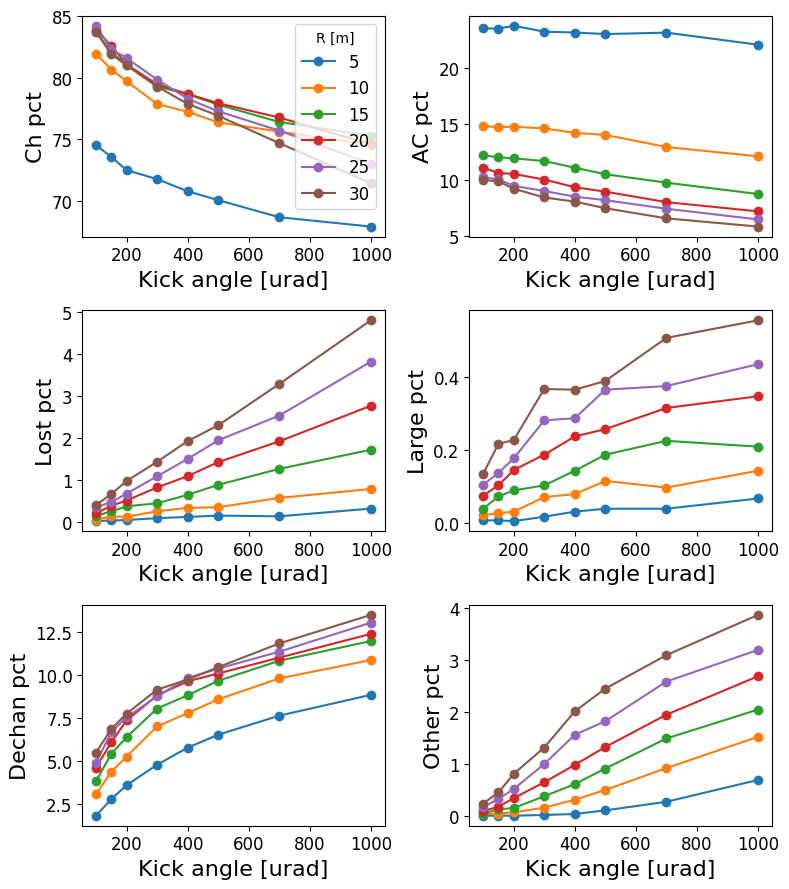

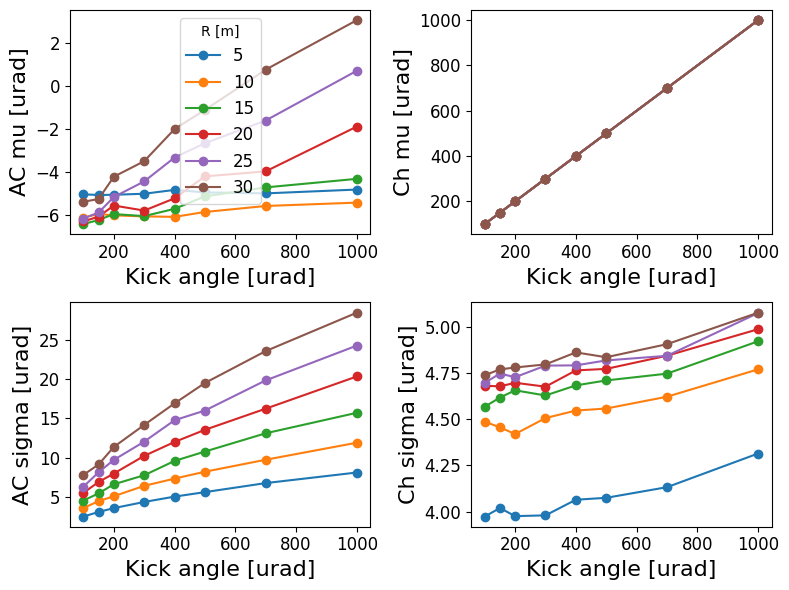

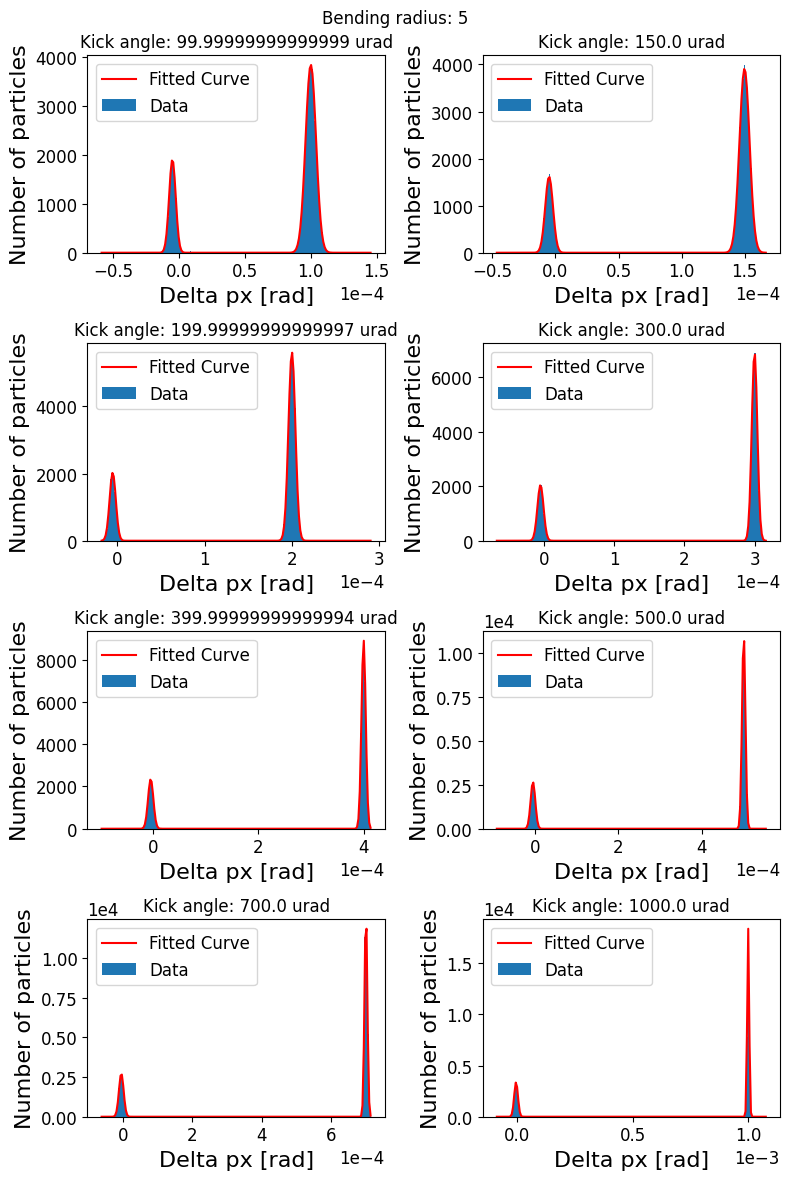

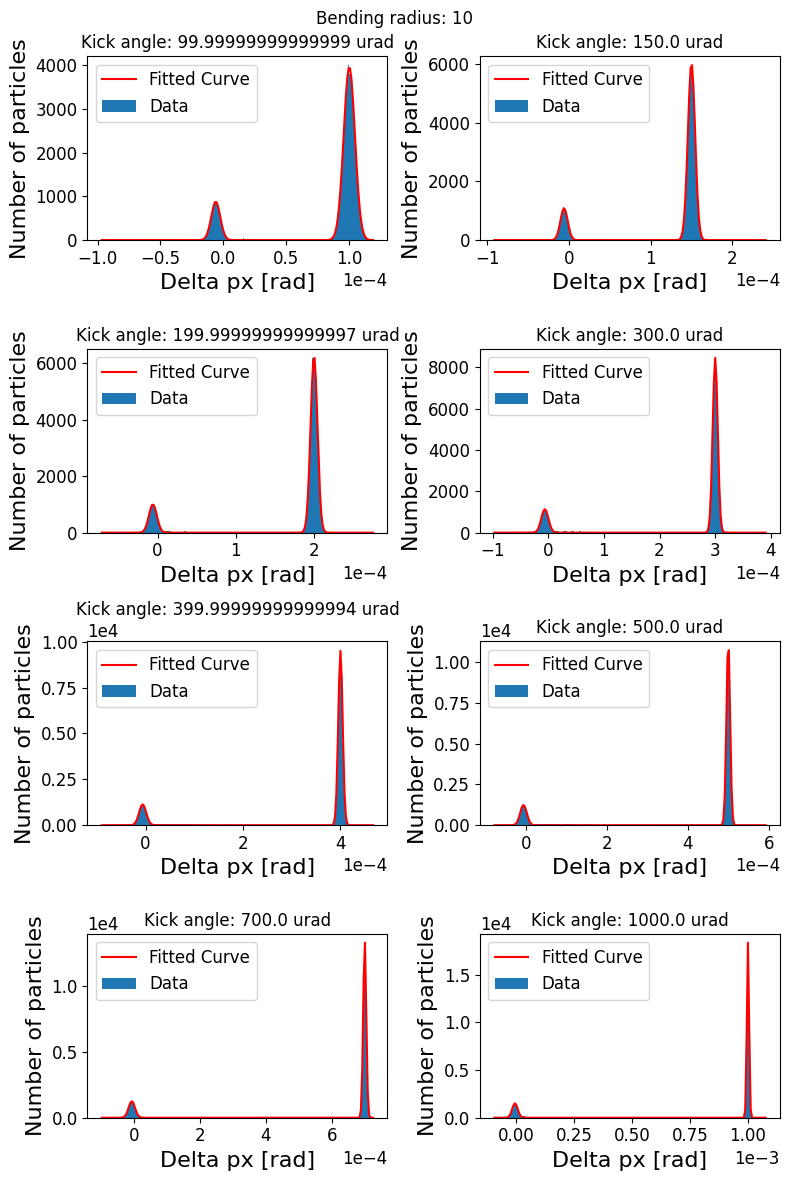

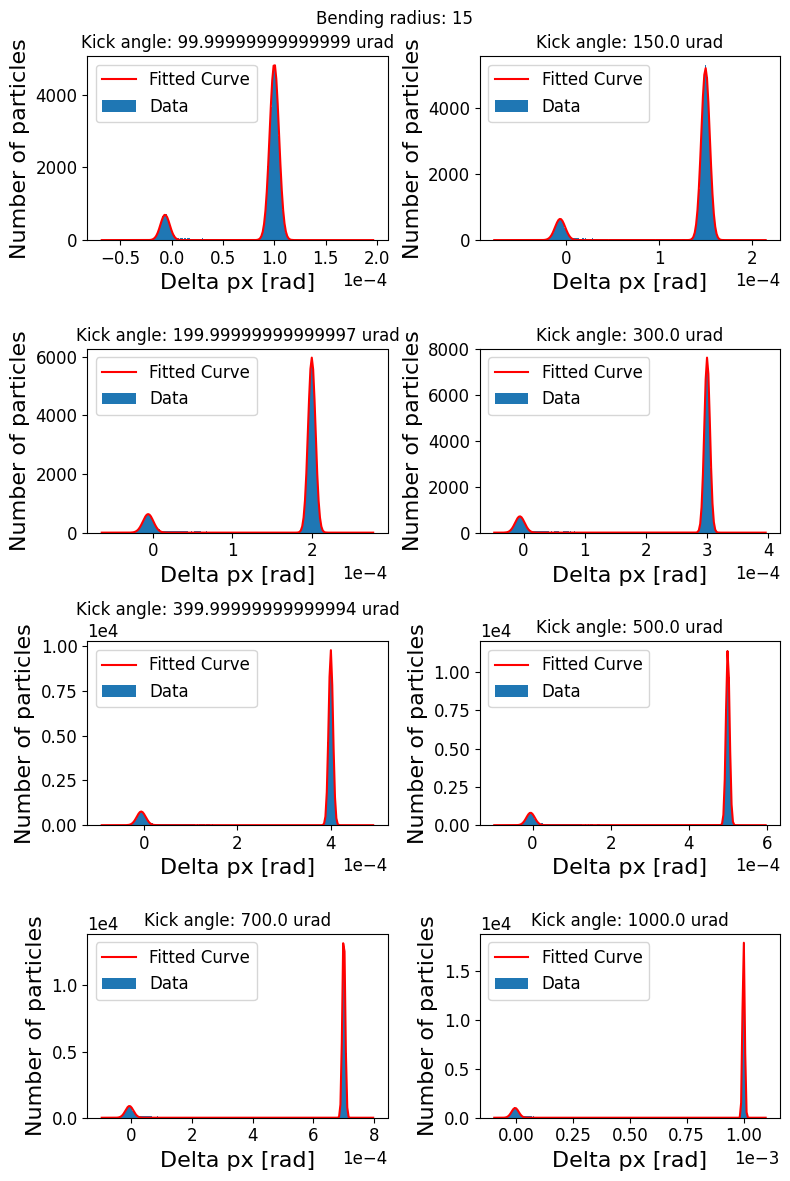

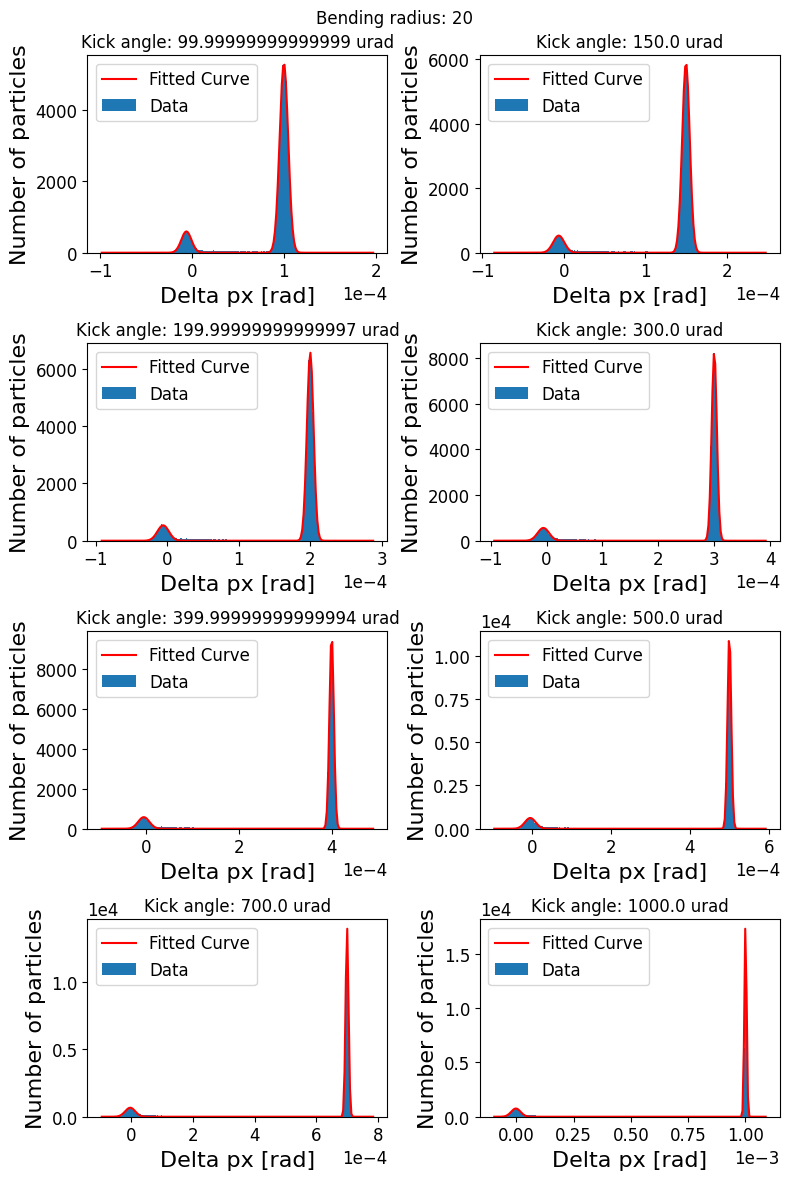

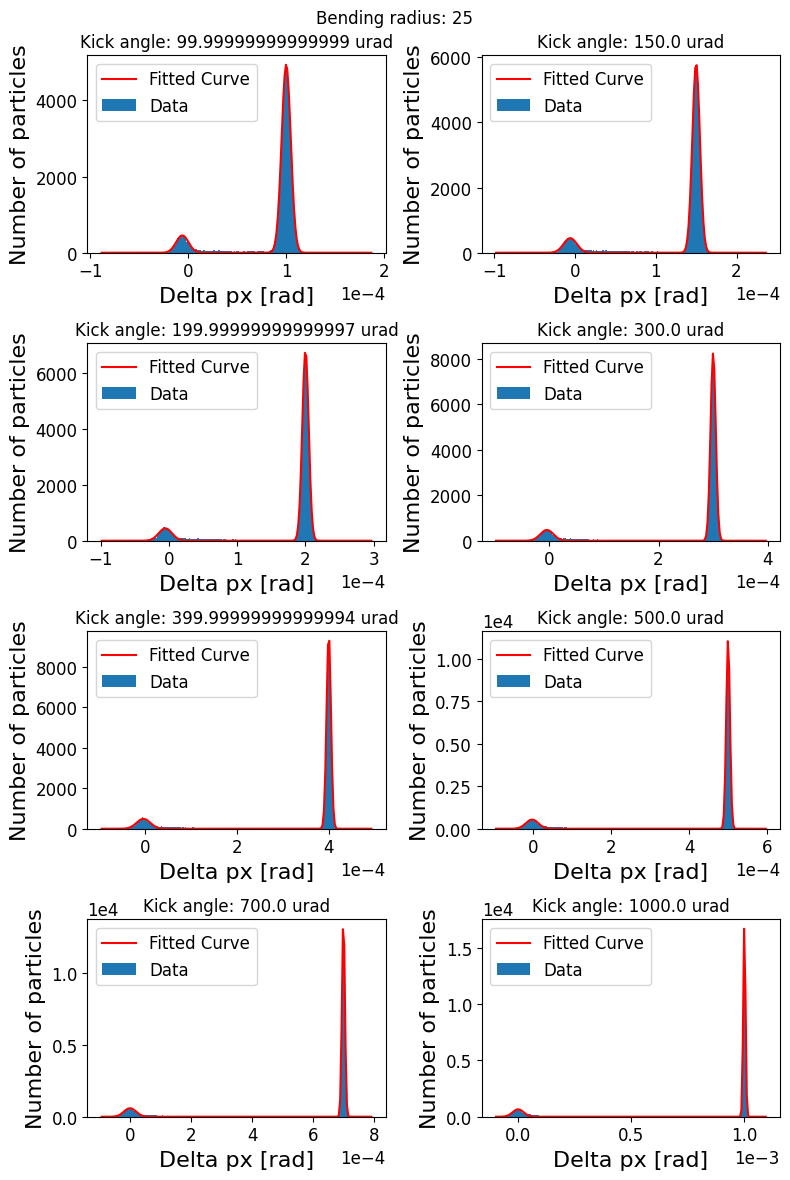

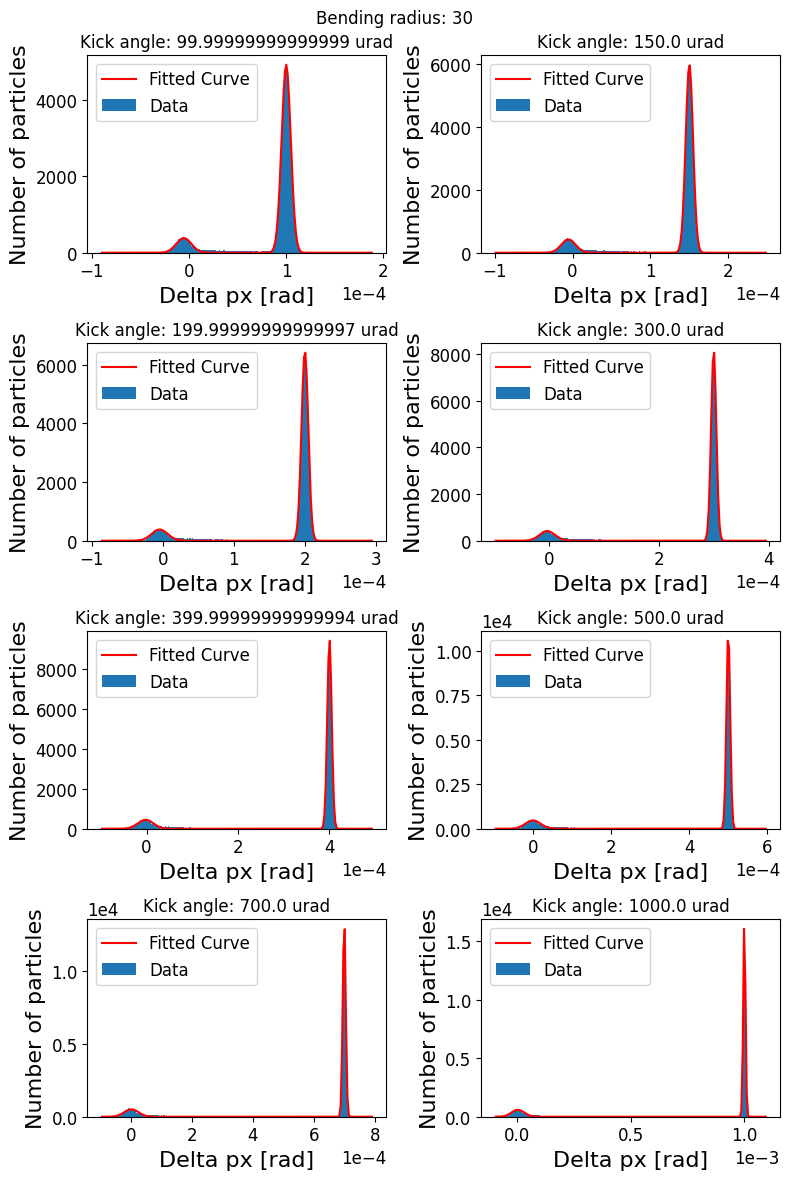

In [7]:
# Regimes are defined with fixed values

bending_radii = np.array([5, 10, 15, 20, 25, 30])
kicks = np.array([100, 150, 200, 300, 400, 500, 700, 1000])*1e-6
n_particles = int(50e3)
nbins = 200
ch_cutoff = 3*5e-6
ac_cutoff = 3*5e-6
p0c = 400e9

f_pct, ax_pct = plotters.subplots(nsubplots=6, col_numbers=[2])
f_stats, ax_stats = plotters.subplots(nsubplots=4, col_numbers=[2])

for bending_radius in bending_radii:
    sps_cry.bending_radius = bending_radius

    lost_pcts = np.zeros_like(kicks)
    other_pcts = np.zeros_like(kicks)
    chan_pcts = np.zeros_like(kicks)
    dechan_pcts = np.zeros_like(kicks)
    ac_pcts = np.zeros_like(kicks)
    large_pcts = np.zeros_like(kicks)
    
    ac_mus = np.zeros_like(kicks)
    ch_mus = np.zeros_like(kicks)
    ac_sigmas = np.zeros_like(kicks)
    ch_sigmas = np.zeros_like(kicks)
    ac_amps = np.zeros_like(kicks)
    ch_amps = np.zeros_like(kicks)
    
    f_fit, ax_fit = plotters.subplots(nsubplots=len(kicks), col_numbers=[2])
    f_fit.suptitle('Bending radius: ' + str(bending_radius))
    
    for i, kick in enumerate(kicks):
        
        # Tracking
        
        sps_cry.mu_kick_chan = kick
        print("Kick angle: ", kick, "radius", sps_cry.bending_radius, "length", sps_cry.active_length)
    
        particles = xp.Particles(p0c=p0c, x=np.zeros(n_particles), px=np.zeros(n_particles), y=np.zeros(n_particles), py=np.zeros(n_particles), zeta=np.zeros(n_particles), delta=np.zeros(n_particles))
        particles._init_random_number_generator()
        cry = sps_cry.build_xsuite_crystal()
        cry.track(particles)
        
        # Analyse the results
            
        all_pxs = particles.px
        lost = particles.state <= 0
        lost_pxs = all_pxs[lost]
        rest_pxs = all_pxs[~lost]
        # Remove some large angle particles by hand
        large_angle = np.logical_or(rest_pxs > kick + 1e-4,
                                     rest_pxs < -1e-4)
        rest_pxs = rest_pxs[~large_angle]
        pxs_hist, pxs_bins = np.histogram(rest_pxs,
                                          bins=nbins)
        pxs_benters = 0.5*(pxs_bins[1:] + pxs_bins[:-1])
        
        
        # Initial guess for the parameters
        initial_guess = [0,
                         sps_cry.sigma_kick_ac,
                         np.max(pxs_hist),
                         kick,
                         sps_cry.sigma_kick_chan,
                         np.max(pxs_hist)]
            
        # Perform the fit
        params, covariance = curve_fit(double_gauss, pxs_benters, pxs_hist, p0=initial_guess)
    
        # Extract fitted parameters
        ac_mu, ac_sigma, ac_amp, ch_mu, ch_sigma, ch_amp = params
    
        # Generate fitted curve
        y_fit = double_gauss(pxs_benters, ac_mu, ac_sigma, ac_amp, ch_mu, ch_sigma, ch_amp)
        
        # Plot the results
        ax_fit[i].bar(pxs_benters, pxs_hist, label='Data', 
               width=pxs_benters[1] - pxs_benters[0])
        ax_fit[i].plot(pxs_benters, y_fit, label='Fitted Curve', color='red')
        ax_fit[i].set_ylabel('Number of particles')
        ax_fit[i].set_xlabel('Delta px [rad]')
        ax_fit[i].set_title('Kick angle: ' + str(kick*1e6) + ' urad')
        ax_fit[i].legend()
        
        # Evaluate performance and save data
        
        lost_pct = np.sum(lost) / n_particles
        lost_pcts[i] = lost_pct
        large_pct = np.sum(large_angle) / n_particles
        large_pcts[i] = large_pct
        chan_pct = np.sum(np.abs(rest_pxs-kick) <= ch_cutoff) / n_particles
        chan_pcts[i] = chan_pct
        ac_pct = np.sum(np.abs(rest_pxs-ac_mu) <= ac_cutoff) / n_particles
        ac_pcts[i] = ac_pct
        dechan_pct = np.sum(np.logical_and(rest_pxs - ac_mu > ac_cutoff,
                                            rest_pxs - kick < -ch_cutoff)) / n_particles   
        dechan_pcts[i] = dechan_pct
        other_pct = 1 - chan_pct - ac_pct - lost_pct - large_pct - dechan_pct
        other_pcts[i] = other_pct
    
        ac_mus[i] = ac_mu
        ch_mus[i] = ch_mu
        ac_sigmas[i] = ac_sigma
        ch_sigmas[i] = ch_sigma
        ac_amps[i] = ac_amp
        ch_amps[i] = ch_amp

    # Plot the results
    
    ax_pct[0].plot(kicks*1e6, chan_pcts*100, label=bending_radius, marker='o')
    ax_pct[0].set_ylabel('Ch pct')
    ax_pct[1].plot(kicks*1e6, ac_pcts*100,
               label=bending_radius, marker='o')
    ax_pct[1].set_ylabel('AC pct')
    ax_pct[2].plot(kicks*1e6, lost_pcts*100, label=bending_radius, marker='o')
    ax_pct[2].set_ylabel('Lost pct')
    ax_pct[3].plot(kicks*1e6, large_pcts*100, marker='o', label=bending_radius)
    ax_pct[3].set_ylabel('Large pct')
    ax_pct[4].plot(kicks*1e6, dechan_pcts*100, marker='o', label=bending_radius)
    ax_pct[4].set_ylabel('Dechan pct')
    ax_pct[5].plot(kicks*1e6, other_pcts*100, marker='o', label=bending_radius)
    ax_pct[5].set_ylabel('Other pct')
    

    ax_stats[0].plot(kicks*1e6, ac_mus*1e6, label=bending_radius, marker='o')
    ax_stats[0].set_ylabel('AC mu [urad]')
    ax_stats[1].plot(kicks*1e6, ch_mus*1e6, label=bending_radius, marker='o')
    ax_stats[1].set_ylabel('Ch mu [urad]')
    ax_stats[2].plot(kicks*1e6, ac_sigmas*1e6, label=bending_radius, marker='o')
    ax_stats[2].set_ylabel('AC sigma [urad]')
    ax_stats[3].plot(kicks*1e6, ch_sigmas*1e6, label=bending_radius, marker='o')
    ax_stats[3].set_ylabel('Ch sigma [urad]')
    
    f_fit.tight_layout()
    
for axis in ax_pct:
    axis.set_xlabel('Kick angle [urad]')
for axis in ax_stats:
    axis.set_xlabel('Kick angle [urad]')

ax_pct[0].legend(title='R [m]')
ax_stats[0].legend(title='R [m]')
f_pct.tight_layout()
f_stats.tight_layout()

In [8]:
# Make a heatmap for fixed kick angle

kick_angle = 300e-6
bending_radii = np.linspace(5, 30, 6)
nbins = 200
bin_range = (-100e-6, kick_angle + 100e-6)
n_particles = int(50e3)
p0c = 400e9

kicks_binned = np.zeros((bending_radii.size, nbins))

for i, bending_radius in enumerate(bending_radii):
    sps_cry.bending_radius = bending_radius
        
    # Tracking
    
    sps_cry.mu_kick_chan = kick_angle
    print("Kick angle: ", kick_angle, "radius", sps_cry.bending_radius, "length", sps_cry.active_length)

    particles = xp.Particles(p0c=p0c, x=np.zeros(n_particles), px=np.zeros(n_particles), y=np.zeros(n_particles), py=np.zeros(n_particles), zeta=np.zeros(n_particles), delta=np.zeros(n_particles))
    particles._init_random_number_generator()
    cry = sps_cry.build_xsuite_crystal()
    cry.track(particles)
    
    # Analyse the results
        
    all_pxs = particles.px
    lost = particles.state < 0
    lost_pxs = all_pxs[lost]
    rest_pxs = all_pxs[~lost]
    # Remove some large angle particles by hand
    large_angle = np.logical_or(rest_pxs > kick + 1e-4,
                                 rest_pxs < -1e-4)
    rest_pxs = rest_pxs[~large_angle]
    pxs_hist, pxs_bins = np.histogram(rest_pxs,
                                      bins=nbins, range=bin_range)
    pxs_benters = 0.5*(pxs_bins[1:] + pxs_bins[:-1])
    kicks_binned[i] = pxs_hist

Kick angle:  0.0003 radius 5.0 length 0.0014999999999999998
Kick angle:  0.0003 radius 10.0 length 0.0029999999999999996
Kick angle:  0.0003 radius 15.0 length 0.0045
Kick angle:  0.0003 radius 20.0 length 0.005999999999999999
Kick angle:  0.0003 radius 25.0 length 0.0075
Kick angle:  0.0003 radius 30.0 length 0.009


Text(0.5, 1.0, 'Kick angle: 300.0 urad')

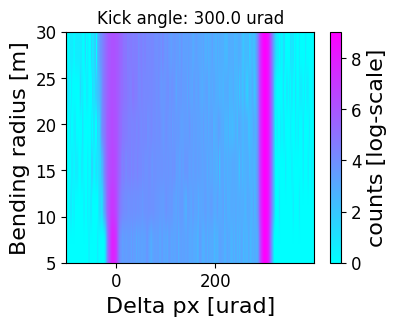

In [9]:
f, ax = plotters.subplots()
m = ax[0].imshow(np.log(kicks_binned + 1),
                 extent=(pxs_benters.min()*1e6, pxs_benters.max()*1e6,
                         bending_radii.min(), bending_radii.max()),
                 origin='lower',
                 aspect='auto',
               cmap='cool')
f.colorbar(m, ax=ax[0], label='counts [log-scale]')
ax[0].set_xlabel('Delta px [urad]')
ax[0].set_ylabel('Bending radius [m]')
ax[0].set_title('Kick angle: ' + str(kick_angle*1e6) + ' urad')

In [10]:
# Make a heatmap for fixed bending radius

bending_radius = 15
kicks = np.linspace(50, 1000, 30)*1e-6
nbins = 200
bin_range = (-100e-6, kicks.max() + 100e-6)
n_particles = int(50e3)
p0c = 400e9

kicks_binned = np.zeros((kicks.size, nbins))
sps_cry.bending_radius = bending_radius

for i, kick_angle in enumerate(kicks):
        
    # Tracking
    
    sps_cry.mu_kick_chan = kick_angle
    print("Kick angle: ", kick_angle, "radius", sps_cry.bending_radius, "length", sps_cry.active_length)

    particles = xp.Particles(p0c=p0c, x=np.zeros(n_particles), px=np.zeros(n_particles), y=np.zeros(n_particles), py=np.zeros(n_particles), zeta=np.zeros(n_particles), delta=np.zeros(n_particles))
    particles._init_random_number_generator()
    cry = sps_cry.build_xsuite_crystal()
    cry.track(particles)
    
    # Analyse the results
        
    all_pxs = particles.px
    lost = particles.state <= 0
    lost_pxs = all_pxs[lost]
    rest_pxs = all_pxs[~lost]
    # Remove some large angle particles by hand
    large_angle = np.logical_or(rest_pxs > kick + 1e-4,
                                 rest_pxs < -1e-4)
    rest_pxs = rest_pxs[~large_angle]
    pxs_hist, pxs_bins = np.histogram(rest_pxs,
                                      bins=nbins, range=bin_range)
    pxs_benters = 0.5*(pxs_bins[1:] + pxs_bins[:-1])
    kicks_binned[i] = pxs_hist

Kick angle:  4.9999999999999996e-05 radius 15 length 0.0007499999999999999
Kick angle:  8.275862068965517e-05 radius 15 length 0.0012413793103448277
Kick angle:  0.00011551724137931034 radius 15 length 0.001732758620689655
Kick angle:  0.00014827586206896551 radius 15 length 0.0022241379310344827
Kick angle:  0.00018103448275862068 radius 15 length 0.0027155172413793104
Kick angle:  0.00021379310344827587 radius 15 length 0.003206896551724138
Kick angle:  0.00024655172413793106 radius 15 length 0.0036982758620689657
Kick angle:  0.0002793103448275862 radius 15 length 0.004189655172413793
Kick angle:  0.0003120689655172414 radius 15 length 0.004681034482758621
Kick angle:  0.0003448275862068966 radius 15 length 0.005172413793103449
Kick angle:  0.0003775862068965517 radius 15 length 0.005663793103448275
Kick angle:  0.0004103448275862069 radius 15 length 0.0061551724137931035
Kick angle:  0.0004431034482758621 radius 15 length 0.006646551724137932
Kick angle:  0.00047586206896551724 rad

Text(0.5, 1.0, 'Bending radius: 15 m')

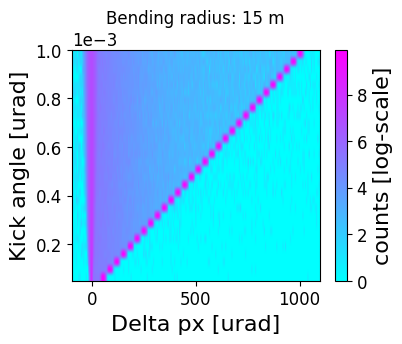

In [11]:
f, ax = plotters.subplots()
m = ax[0].imshow(np.log(kicks_binned + 1),
                 extent=(pxs_benters.min()*1e6, pxs_benters.max()*1e6,
                         kicks.min(), kicks.max()),
                 origin='lower',
                 aspect='auto',
               cmap='cool')
f.colorbar(m, ax=ax[0], label='counts [log-scale]')
ax[0].set_xlabel('Delta px [urad]')
ax[0].set_ylabel('Kick angle [urad]')
ax[0].set_title('Bending radius: ' + str(bending_radius) + ' m')